# NSL-KDD Intrusion Detection System
## KDDTrain+ / KDDTest+ (Separate Files)

Training on `KDDTrain+.txt`, evaluating on the official `KDDTest+.txt` — a harder, more realistic test set with unseen attack types.

**Feature Selection Methods:** Variance Threshold · Pearson Correlation · ANOVA F-Score · PCA  
**Models:** Random Forest · SVM · XGBoost · MLP  
**Tuning:** GridSearchCV for highest model accuracy

## 1. Imports & Setup

In [1]:
import warnings
import os
import time

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import VarianceThreshold, f_classif, SelectKBest
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.base import clone

from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input

print("All imports successful.")
print(f"TensorFlow: {tf.__version__}")

All imports successful.
TensorFlow: 2.21.0


## 2. Data Loading

> **v1 distinction:** `KDDTrain+.txt` is used for training and `KDDTest+.txt` as the official test set.  
> `KDDTest+` contains novel attack types not present in training, making it a harder and more realistic benchmark.

In [2]:
col_names = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label","level"
]

# Load separate train and test files
data      = pd.read_csv("data/KDDTrain+.txt", header=None, names=col_names)
test_data = pd.read_csv("data/KDDTest+.txt",  header=None, names=col_names)

print(f"Train shape : {data.shape}")
print(f"Test  shape : {test_data.shape}")

# Confirm unique attack types in test but NOT in train
train_labels = set(data['label'].unique())
test_labels  = set(test_data['label'].unique())
novel_attacks = test_labels - train_labels
print(f"\nNovel attack types in KDDTest+ (unseen during training): {len(novel_attacks)}")
print(sorted(novel_attacks))

Train shape : (125973, 43)
Test  shape : (22544, 43)

Novel attack types in KDDTest+ (unseen during training): 17
['apache2', 'httptunnel', 'mailbomb', 'mscan', 'named', 'processtable', 'ps', 'saint', 'sendmail', 'snmpgetattack', 'snmpguess', 'sqlattack', 'udpstorm', 'worm', 'xlock', 'xsnoop', 'xterm']


## 3. Exploratory Data Analysis

In [3]:
print(f"Train — shape: {data.shape}  |  missing: {data.isnull().sum().sum()}  |  duplicates: {data.duplicated().sum()}")
print(f"Test  — shape: {test_data.shape}  |  missing: {test_data.isnull().sum().sum()}")
print("\nTrain label distribution:")
print(data['label'].value_counts())

Train — shape: (125973, 43)  |  missing: 0  |  duplicates: 0
Test  — shape: (22544, 43)  |  missing: 0

Train label distribution:
label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


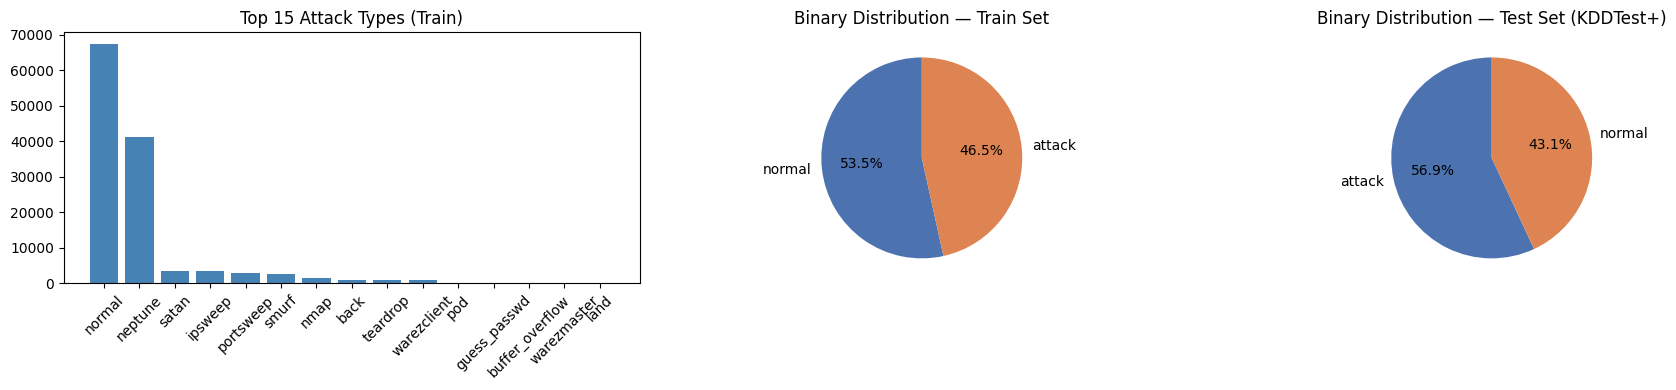

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Attack type distribution — train
top_labels = data['label'].value_counts().head(15)
axes[0].bar(top_labels.index, top_labels.values, color='steelblue')
axes[0].set_title('Top 15 Attack Types (Train)')
axes[0].tick_params(axis='x', rotation=45)

# Binary distribution — train vs test (pie)
for ax, df_, title in zip(axes[1:], [data, test_data], ['Train Set', 'Test Set (KDDTest+)']):
    bin_label = df_['label'].apply(lambda x: 'normal' if x == 'normal' else 'attack')
    counts    = bin_label.value_counts()
    ax.pie(counts, labels=counts.index, autopct='%1.1f%%',
           colors=['#4C72B0', '#DD8452'], startangle=90)
    ax.set_title(f'Binary Distribution — {title}')

plt.tight_layout()
plt.show()

## 4. Preprocessing

In [5]:
df      = data.copy()
test_df = test_data.copy()

# Drop constant/redundant columns
df.drop(["num_outbound_cmds", "level"], axis=1, inplace=True)
test_df.drop(["num_outbound_cmds", "level"], axis=1, inplace=True)

# Binary labels: 0 = normal, 1 = attack
df["binary_label"]      = df["label"].apply(lambda x: 0 if x == "normal" else 1)
test_df["binary_label"] = test_df["label"].apply(lambda x: 0 if x == "normal" else 1)

# Split features / labels
cat_cols = ["protocol_type", "service", "flag"]
X_train_raw = df.drop(columns=["label", "binary_label"])
y_train     = df["binary_label"]
X_test_raw  = test_df.drop(columns=["label", "binary_label"])
y_test      = test_df["binary_label"]

numeric_raw_cols = [c for c in X_train_raw.columns if c not in cat_cols]

# One-Hot Encode categorical features (fit ONLY on train to prevent leakage)
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
col_transformer = ColumnTransformer(
    transformers=[
        ("ohe", ohe, cat_cols),
        ("passthrough", "passthrough", numeric_raw_cols)
    ]
)
X_train = col_transformer.fit_transform(X_train_raw)
X_test  = col_transformer.transform(X_test_raw)

ohe_feature_names = col_transformer.named_transformers_['ohe'].get_feature_names_out(cat_cols).tolist()
all_feature_names = ohe_feature_names + numeric_raw_cols
X_train = pd.DataFrame(X_train, columns=all_feature_names)
X_test  = pd.DataFrame(X_test,  columns=all_feature_names)

print(f"X_train: {X_train.shape}  X_test: {X_test.shape}")
print(f"y_train — normal:{(y_train==0).sum()}  attack:{(y_train==1).sum()}")
print(f"y_test  — normal:{(y_test==0).sum()}   attack:{(y_test==1).sum()}")

X_train: (125973, 121)  X_test: (22544, 121)
y_train — normal:67343  attack:58630
y_test  — normal:9711   attack:12833


In [6]:
# Log1p transform for highly skewed numeric features
ohe_cols_set      = set(ohe_feature_names)
numeric_only_cols = [c for c in X_train.columns if c not in ohe_cols_set]
skewness          = X_train[numeric_only_cols].skew()
high_skew_cols    = skewness[skewness > 0.75].index.tolist()

X_train_log = X_train.copy()
X_test_log  = X_test.copy()
for col in high_skew_cols:
    if (X_train_log[col] >= 0).all() and (X_test_log[col] >= 0).all():
        X_train_log[col] = np.log1p(X_train_log[col])
        X_test_log[col]  = np.log1p(X_test_log[col])

# Standard scaling (fit ONLY on train)
scaler         = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_log),
    columns=X_train_log.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_log),
    columns=X_test_log.columns
)

feature_names = np.array(X_train_scaled.columns.tolist())
print(f"Skewed columns log-transformed : {len(high_skew_cols)}")
print(f"Final feature count            : {len(feature_names)}")

Skewed columns log-transformed : 32
Final feature count            : 121


## 5. Feature Selection

Four methods applied. All selectors **fit exclusively on training data** — `KDDTest+` is never seen during selection.

In [7]:
# ── 5.1 Variance Threshold ────────────────────────────────────────
vt = VarianceThreshold(threshold=0.01)
X_tr_vt = vt.fit_transform(X_train_log)
X_te_vt = vt.transform(X_test_log)
vt_features = X_train_log.columns[vt.get_support()]

print(f"Variance Threshold → kept {X_tr_vt.shape[1]} / {len(feature_names)} features")
print(f"Removed: {list(X_train_log.columns[~vt.get_support()])}")

Variance Threshold → kept 45 / 121 features
Removed: ['service_IRC', 'service_X11', 'service_Z39_50', 'service_aol', 'service_auth', 'service_bgp', 'service_courier', 'service_csnet_ns', 'service_ctf', 'service_daytime', 'service_discard', 'service_domain', 'service_echo', 'service_efs', 'service_exec', 'service_gopher', 'service_harvest', 'service_hostnames', 'service_http_2784', 'service_http_443', 'service_http_8001', 'service_imap4', 'service_iso_tsap', 'service_klogin', 'service_kshell', 'service_ldap', 'service_link', 'service_login', 'service_mtp', 'service_name', 'service_netbios_dgm', 'service_netbios_ns', 'service_netbios_ssn', 'service_netstat', 'service_nnsp', 'service_nntp', 'service_ntp_u', 'service_pm_dump', 'service_pop_2', 'service_pop_3', 'service_printer', 'service_red_i', 'service_remote_job', 'service_rje', 'service_shell', 'service_sql_net', 'service_ssh', 'service_sunrpc', 'service_supdup', 'service_systat', 'service_tftp_u', 'service_tim_i', 'service_time', 'ser

Pearson Correlation → kept 114 features
Dropped (|r| > 0.90): ['serror_rate', 'srv_serror_rate', 'srv_rerror_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']


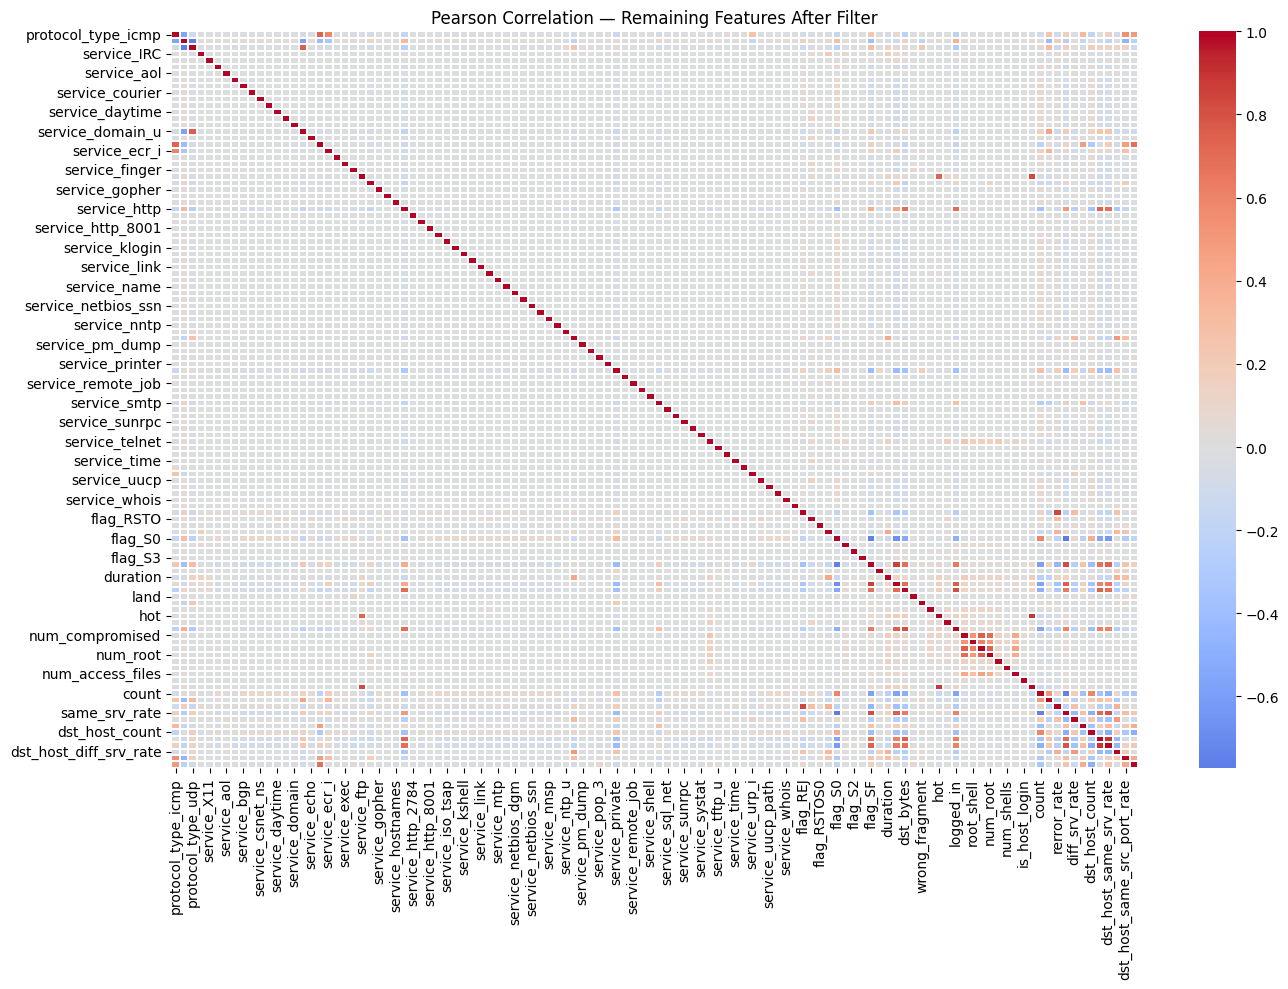

In [8]:
# ── 5.2 Pearson Correlation Filter ───────────────────────────────
corr_mat  = X_train_log.corr().abs()
upper     = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
drop_corr = [c for c in upper.columns if any(upper[c] > 0.90)]

X_tr_pc = X_train_log.drop(columns=drop_corr)
X_te_pc = X_test_log.drop(columns=drop_corr)
pc_features = np.array(X_tr_pc.columns.tolist())

print(f"Pearson Correlation → kept {X_tr_pc.shape[1]} features")
print(f"Dropped (|r| > 0.90): {drop_corr}")

# Correlation heatmap of remaining features
plt.figure(figsize=(14, 10))
sns.heatmap(X_tr_pc.corr(), cmap="coolwarm", center=0, linewidths=0.3, annot=False)
plt.title("Pearson Correlation — Remaining Features After Filter")
plt.tight_layout()
plt.show()

In [25]:
# ── 5.3 ANOVA F-Score ────────────────────────────────────────────
f_scores, f_pvals = f_classif(X_train_scaled, y_train)

# Keep p <= 0.05, then select top-K by median F threshold
sig_mask     = f_pvals <= 0.05
sig_f_scores = f_scores[sig_mask]
sig_features = feature_names[sig_mask]
f_median     = np.median(sig_f_scores)
top_mask     = sig_f_scores >= f_median
anova_k      = int(top_mask.sum())

sel_anova  = SelectKBest(f_classif, k=anova_k)
X_tr_anova = sel_anova.fit_transform(X_train_scaled, y_train)
X_te_anova = sel_anova.transform(X_test_scaled)

print(f"ANOVA F-Score → kept {anova_k} features (p≤0.05, F≥median {f_median:.1f})")

ANOVA F-Score → kept 55 features (p≤0.05, F≥median 552.4)


PCA 95% variance → 87 components, shape: (125973, 87)
PCA k=20          → shape: (125973, 20)


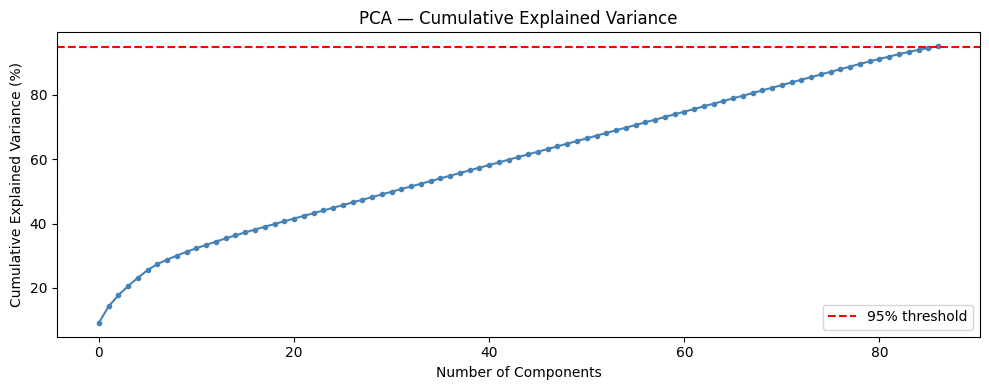

In [10]:
# ── 5.4 PCA ──────────────────────────────────────────────────────
pca_95     = PCA(n_components=0.95, random_state=42)
X_tr_pca95 = pca_95.fit_transform(X_train_scaled)
X_te_pca95 = pca_95.transform(X_test_scaled)

pca_20     = PCA(n_components=20, random_state=42)
X_tr_pca20 = pca_20.fit_transform(X_train_scaled)
X_te_pca20 = pca_20.transform(X_test_scaled)

print(f"PCA 95% variance → {pca_95.n_components_} components, shape: {X_tr_pca95.shape}")
print(f"PCA k=20          → shape: {X_tr_pca20.shape}")

plt.figure(figsize=(10, 4))
plt.plot(np.cumsum(pca_95.explained_variance_ratio_) * 100,
         marker="o", markersize=3, color="steelblue")
plt.axhline(95, color="red", linestyle="--", label="95% threshold")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("PCA — Cumulative Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# Feature sets dictionary
feature_sets = {
    "01_variance_thresh": (X_tr_vt,        X_te_vt),
    "02_pearson_corr":    (X_tr_pc,        X_te_pc),
    "03_anova_f":         (X_tr_anova,     X_te_anova),
    "04_pca_95pct":       (X_tr_pca95,     X_te_pca95),
    "05_pca_k20":         (X_tr_pca20,     X_te_pca20),
}

print(f"{'Feature Set':<22}  Train Shape      Test Shape")
print("-" * 55)
for name, (Xtr, Xte) in feature_sets.items():
    print(f"{name:<22}  {str(np.array(Xtr).shape):<16}  {np.array(Xte).shape}")

Feature Set             Train Shape      Test Shape
-------------------------------------------------------
01_variance_thresh      (125973, 45)      (22544, 45)
02_pearson_corr         (125973, 114)     (22544, 114)
03_anova_f              (125973, 55)      (22544, 55)
04_pca_95pct            (125973, 87)      (22544, 87)
05_pca_k20              (125973, 20)      (22544, 20)


## 6. Model Definitions

| Model | Key Parameters |
|-------|---------------|
| **RF** | n_estimators=200, max_depth=20, random_state=50 |
| **SVM** | C=1.0, kernel='rbf', degree=3, gamma='scale' |
| **XGBoost** | n_estimators=200, max_depth=6, lr=0.1 |
| **MLP** | Dense(300→200→100, relu) → Dropout(0.5) → Softmax(2) |

In [12]:
# Random Forest
model_RF = RandomForestClassifier(
    n_estimators = 200,
    max_depth    = 20,
    random_state = 50,
    n_jobs       = -1,
    class_weight = "balanced"
)

# SVM
model_SVM = SVC(
    C           = 1.0,
    kernel      = "rbf",
    degree      = 3,
    gamma       = "scale",
    probability = True,
    random_state= 42,
    class_weight= "balanced"
)

# XGBoost
try:
    import subprocess
    subprocess.check_output(["nvidia-smi"], timeout=3)
    xgb_device = "cuda"
except Exception:
    xgb_device = "cpu"

model_XGB = XGBClassifier(
    n_estimators     = 200,
    max_depth        = 6,
    learning_rate    = 0.1,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    eval_metric      = "logloss",
    device           = xgb_device,
    n_jobs           = 1
)
print(f"XGBoost device: {xgb_device}")

# MLP builder
def build_mlp(input_dim):
    """
    Dense(300, relu) → BN → Dense(200, relu) → BN → Dense(100, relu)
    → Dropout(0.5) → Dense(2, softmax)
    """
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(300, activation="relu"),
        BatchNormalization(),
        Dense(200, activation="relu"),
        BatchNormalization(),
        Dense(100, activation="relu"),
        Dropout(0.5),
        Dense(2,   activation="softmax")
    ])
    model.compile(
        optimizer = "adam",
        loss      = "sparse_categorical_crossentropy",
        metrics   = ["accuracy"]
    )
    return model

build_mlp(10).summary()

XGBoost device: cuda


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 300)            │         3,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 300)            │         1,200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │        60,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 200)            │           800 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           202 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,802 (335.16 KB)

 Trainable params: 84,802 (331.26 KB)

 Non-trainable params: 1,000 (3.91 KB)

## 7. Evaluation Helper

In [26]:
def evaluate(y_true, y_pred, y_prob=None):
    metrics = {
        "accuracy"   : round(accuracy_score(y_true, y_pred), 4),
        "precision"  : round(precision_score(y_true, y_pred, average="weighted", zero_division=0), 4),
        "recall"     : round(recall_score(y_true, y_pred, average="weighted", zero_division=0), 4),
        "f1_weighted": round(f1_score(y_true, y_pred, average="weighted", zero_division=0), 4),
        "f1_macro"   : round(f1_score(y_true, y_pred, average="macro", zero_division=0), 4),
    }
    if y_prob is not None:
        prob = y_prob[:, 1] if y_prob.ndim == 2 else y_prob
        try:
            metrics["roc_auc"] = round(roc_auc_score(y_true, prob), 4)
        except Exception:
            metrics["roc_auc"] = None
    else:
        metrics["roc_auc"] = None
    return metrics

## 8. Training & Evaluation Loop

In [14]:
results         = []
best_estimators = {fs: {} for fs in feature_sets}
SVM_MAX_ROWS    = 30_000

for fs_name, (X_tr, X_te) in feature_sets.items():
    X_tr = np.array(X_tr)
    X_te = np.array(X_te)
    print(f"\n{'='*60}")
    print(f"Feature Set: {fs_name}  |  shape: {X_tr.shape}")
    print('='*60)

    # ── RF ───────────────────────────────────────────────────────
    print("[RF]")
    t0 = time.time()
    m  = clone(model_RF)
    m.fit(X_tr, y_train)
    yp   = m.predict(X_te)
    yprb = m.predict_proba(X_te)
    met  = evaluate(y_test, yp, yprb)
    elapsed = round(time.time() - t0, 2)
    print(f"  acc={met['accuracy']}  f1={met['f1_weighted']}  roc={met['roc_auc']}  ({elapsed}s)")
    results.append({"feature_set": fs_name, "model": "RF", "time_s": elapsed, **met})
    best_estimators[fs_name]["RF"] = m

    # ── SVM ──────────────────────────────────────────────────────
    print("[SVM]")
    t0  = time.time()
    m   = clone(model_SVM)
    idx = np.random.default_rng(42).choice(len(X_tr), min(SVM_MAX_ROWS, len(X_tr)), replace=False)
    m.fit(X_tr[idx], y_train.iloc[idx])
    yp   = m.predict(X_te)
    yprb = m.predict_proba(X_te)
    met  = evaluate(y_test, yp, yprb)
    elapsed = round(time.time() - t0, 2)
    print(f"  acc={met['accuracy']}  f1={met['f1_weighted']}  roc={met['roc_auc']}  ({elapsed}s)")
    results.append({"feature_set": fs_name, "model": "SVM", "time_s": elapsed, **met})
    best_estimators[fs_name]["SVM"] = m

    # ── XGBoost ──────────────────────────────────────────────────
    print("[XGB]")
    t0 = time.time()
    m  = clone(model_XGB)
    m.fit(X_tr, y_train)
    yp   = m.predict(X_te)
    yprb = m.predict_proba(X_te)
    met  = evaluate(y_test, yp, yprb)
    elapsed = round(time.time() - t0, 2)
    print(f"  acc={met['accuracy']}  f1={met['f1_weighted']}  roc={met['roc_auc']}  ({elapsed}s)")
    results.append({"feature_set": fs_name, "model": "XGB", "time_s": elapsed, **met})
    best_estimators[fs_name]["XGB"] = m

    # ── MLP ──────────────────────────────────────────────────────
    print("[MLP]")
    t0  = time.time()
    mlp = build_mlp(X_tr.shape[1])
    mlp.fit(
        X_tr, y_train,
        validation_split = 0.1,
        epochs           = 20,
        batch_size       = 256,
        callbacks        = [tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)],
        verbose          = 0
    )
    yp   = np.argmax(mlp.predict(X_te, verbose=0), axis=1)
    yprb = mlp.predict(X_te, verbose=0)
    met  = evaluate(y_test, yp, yprb)
    elapsed = round(time.time() - t0, 2)
    print(f"  acc={met['accuracy']}  f1={met['f1_weighted']}  roc={met['roc_auc']}  ({elapsed}s)")
    results.append({"feature_set": fs_name, "model": "MLP", "time_s": elapsed, **met})
    best_estimators[fs_name]["MLP"] = mlp

print("\nTraining complete.")


Feature Set: 01_variance_thresh  |  shape: (125973, 45)
[RF]
  acc=0.7596  f1=0.7555  roc=0.9667  (8.25s)
[SVM]
  acc=0.7365  f1=0.731  roc=0.9067  (204.82s)
[XGB]
  acc=0.7869  f1=0.7848  roc=0.9718  (1.54s)
[MLP]
  acc=0.7818  f1=0.7812  roc=0.9392  (28.48s)

Feature Set: 02_pearson_corr  |  shape: (125973, 114)
[RF]
  acc=0.7738  f1=0.7709  roc=0.963  (10.08s)
[SVM]
  acc=0.7362  f1=0.7308  roc=0.9065  (321.3s)
[XGB]
  acc=0.7834  f1=0.7811  roc=0.9676  (2.88s)
[MLP]
  acc=0.7877  f1=0.7871  roc=0.9366  (22.52s)

Feature Set: 03_anova_f  |  shape: (125973, 55)
[RF]
  acc=0.7699  f1=0.7666  roc=0.9617  (7.51s)
[SVM]
  acc=0.7887  f1=0.7884  roc=0.8764  (30.17s)
[XGB]
  acc=0.789  f1=0.787  roc=0.9691  (1.73s)
[MLP]
  acc=0.8037  f1=0.8029  roc=0.9373  (33.06s)

Feature Set: 04_pca_95pct  |  shape: (125973, 87)
[RF]
  acc=0.7905  f1=0.7904  roc=0.956  (47.29s)
[SVM]
  acc=0.799  f1=0.7991  roc=0.9389  (55.19s)
[XGB]
  acc=0.7888  f1=0.7884  roc=0.9611  (3.82s)
[MLP]
  acc=0.8203  f1=

## 9. Results Comparison

In [15]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(["accuracy", "f1_weighted"], ascending=False).reset_index(drop=True)

print("All Results — sorted by Accuracy:")
display(results_df[["feature_set","model","accuracy","f1_weighted","f1_macro","roc_auc","time_s"]])

print("\nBest result per model:")
display(
    results_df.groupby("model")
              .apply(lambda g: g.nlargest(1, "accuracy"))
              .reset_index(drop=True)[["model","feature_set","accuracy","f1_weighted","roc_auc"]]
)

All Results — sorted by Accuracy:


,feature_set,model,accuracy,f1_weighted,f1_macro,roc_auc,time_s
0,04_pca_95pct,MLP,0.8203,0.8198,0.8202,0.9032,27.63
1,05_pca_k20,XGB,0.8116,0.8107,0.8114,0.9647,1.42
2,05_pca_k20,MLP,0.8111,0.8114,0.8111,0.9045,19.65
3,05_pca_k20,RF,0.8088,0.8079,0.8086,0.9624,20.21
4,03_anova_f,MLP,0.8037,0.8029,0.8036,0.9373,33.06
5,04_pca_95pct,SVM,0.7990,0.7991,0.7990,0.9389,55.19
6,04_pca_95pct,RF,0.7905,0.7904,0.7905,0.9560,47.29
7,03_anova_f,XGB,0.7890,0.7870,0.7885,0.9691,1.73
8,05_pca_k20,SVM,0.7888,0.7885,0.7888,0.9411,16.86
9,04_pca_95pct,XGB,0.7888,0.7884,0.7887,0.9611,3.82



Best result per model:


,model,feature_set,accuracy,f1_weighted,roc_auc
0,MLP,04_pca_95pct,0.8203,0.8198,0.9032
1,RF,05_pca_k20,0.8088,0.8079,0.9624
2,SVM,04_pca_95pct,0.7990,0.7991,0.9389
3,XGB,05_pca_k20,0.8116,0.8107,0.9647


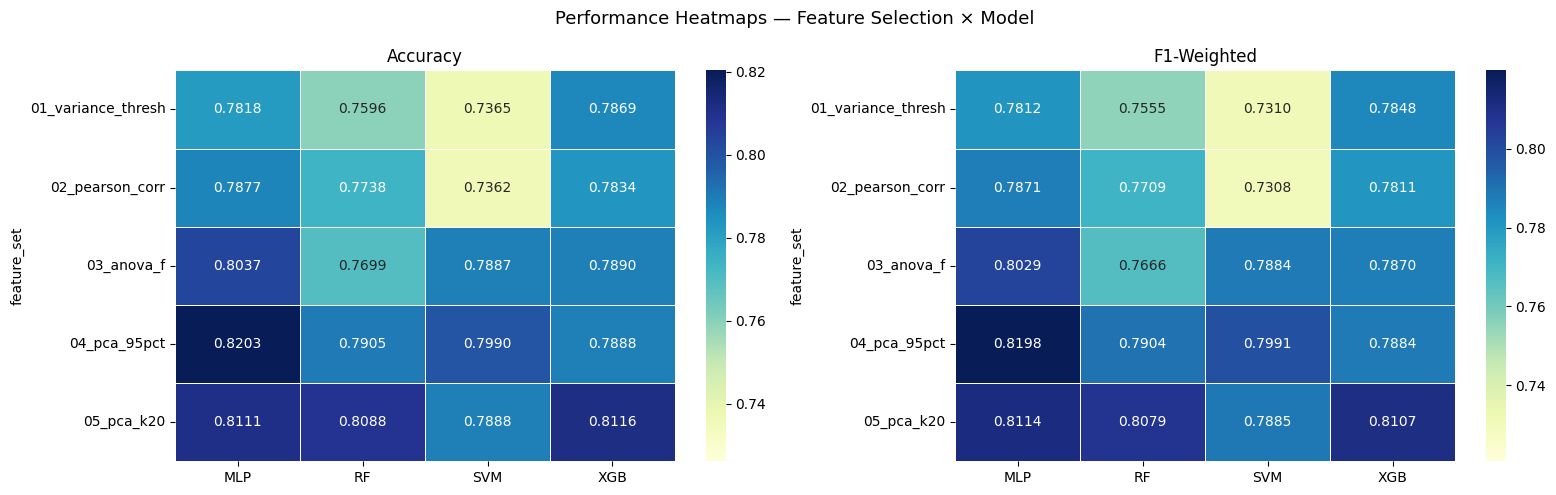

In [16]:
# Dual heatmaps: Accuracy and F1-Weighted
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

heat_acc = results_df.pivot_table(index="feature_set", columns="model", values="accuracy")
sns.heatmap(heat_acc, annot=True, fmt=".4f", cmap="YlGnBu", ax=axes[0],
            linewidths=0.5, vmin=heat_acc.values.min() - 0.01)
axes[0].set_title("Accuracy")
axes[0].set_xlabel("")

heat_f1 = results_df.pivot_table(index="feature_set", columns="model", values="f1_weighted")
sns.heatmap(heat_f1, annot=True, fmt=".4f", cmap="YlGnBu", ax=axes[1],
            linewidths=0.5, vmin=heat_f1.values.min() - 0.01)
axes[1].set_title("F1-Weighted")
axes[1].set_xlabel("")

plt.suptitle("Performance Heatmaps — Feature Selection × Model", fontsize=13)
plt.tight_layout()
plt.show()

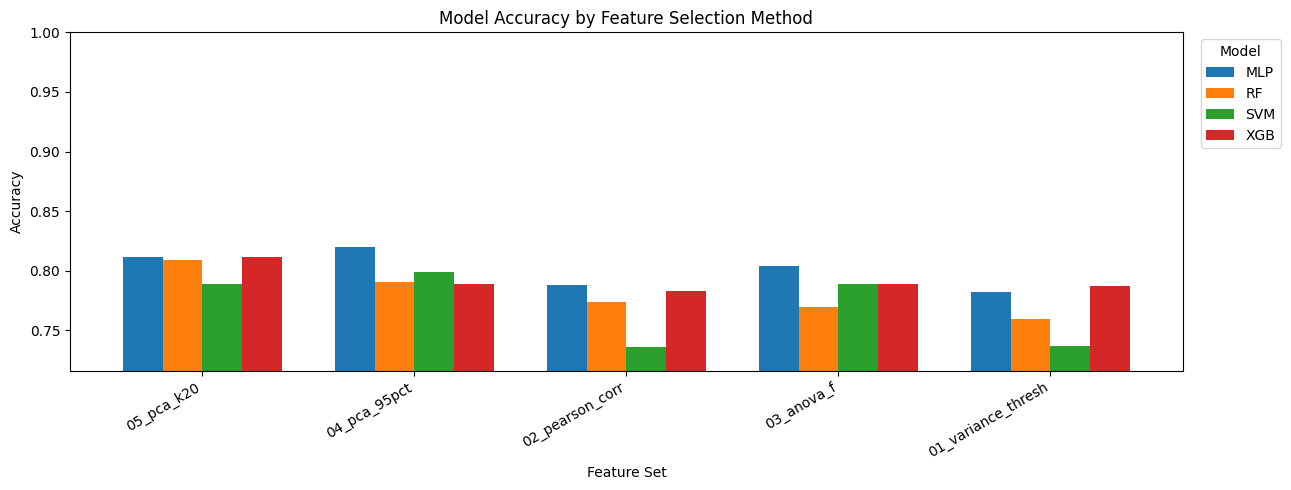

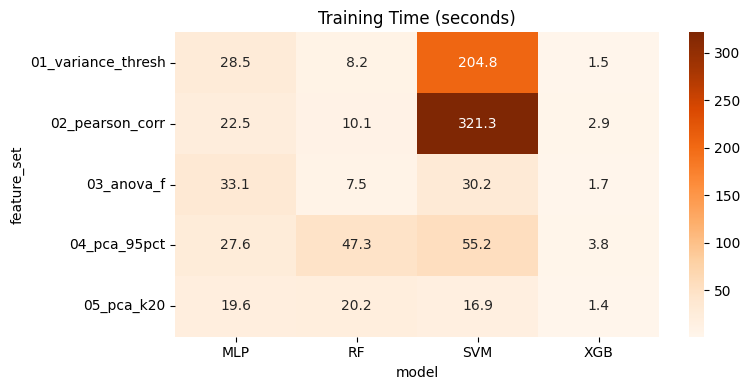

In [17]:
# Grouped bar chart + Training time heatmap
pivot = results_df.pivot_table(index="feature_set", columns="model", values="accuracy")
pivot = pivot.sort_values("RF", ascending=False)

ax = pivot.plot(kind="bar", figsize=(13, 5), width=0.75)
ax.set_title("Model Accuracy by Feature Selection Method")
ax.set_xlabel("Feature Set")
ax.set_ylabel("Accuracy")
ax.set_ylim(pivot.values.min() - 0.02, 1.0)
ax.legend(title="Model", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

heat_t = results_df.pivot_table(index="feature_set", columns="model", values="time_s")
plt.figure(figsize=(8, 4))
sns.heatmap(heat_t, annot=True, fmt=".1f", cmap="Oranges")
plt.title("Training Time (seconds)")
plt.tight_layout()
plt.show()

## 10. Best Model — Detailed Evaluation

In [18]:
best_row   = results_df.iloc[0]
best_fs    = best_row["feature_set"]
best_model = best_row["model"]
print(f"Best combination : {best_model}  on  {best_fs}")
print(f"Accuracy         : {best_row['accuracy']}")
print(f"F1-Weighted      : {best_row['f1_weighted']}")
print(f"ROC-AUC          : {best_row['roc_auc']}")

X_best_tr, X_best_te = feature_sets[best_fs]
X_best_tr = np.array(X_best_tr)
X_best_te = np.array(X_best_te)
m_best    = best_estimators[best_fs][best_model]

if best_model == "MLP":
    yp_best   = np.argmax(m_best.predict(X_best_te, verbose=0), axis=1)
    yprb_best = m_best.predict(X_best_te, verbose=0)
else:
    yp_best   = m_best.predict(X_best_te)
    yprb_best = m_best.predict_proba(X_best_te)

print("\nClassification Report:")
print(classification_report(y_test, yp_best, target_names=["normal", "attack"]))

Best combination : MLP  on  04_pca_95pct
Accuracy         : 0.8203
F1-Weighted      : 0.8198
ROC-AUC          : 0.9032

Classification Report:
              precision    recall  f1-score   support

      normal       0.71      0.97      0.82      9711
      attack       0.97      0.70      0.82     12833

    accuracy                           0.82     22544
   macro avg       0.84      0.84      0.82     22544
weighted avg       0.86      0.82      0.82     22544



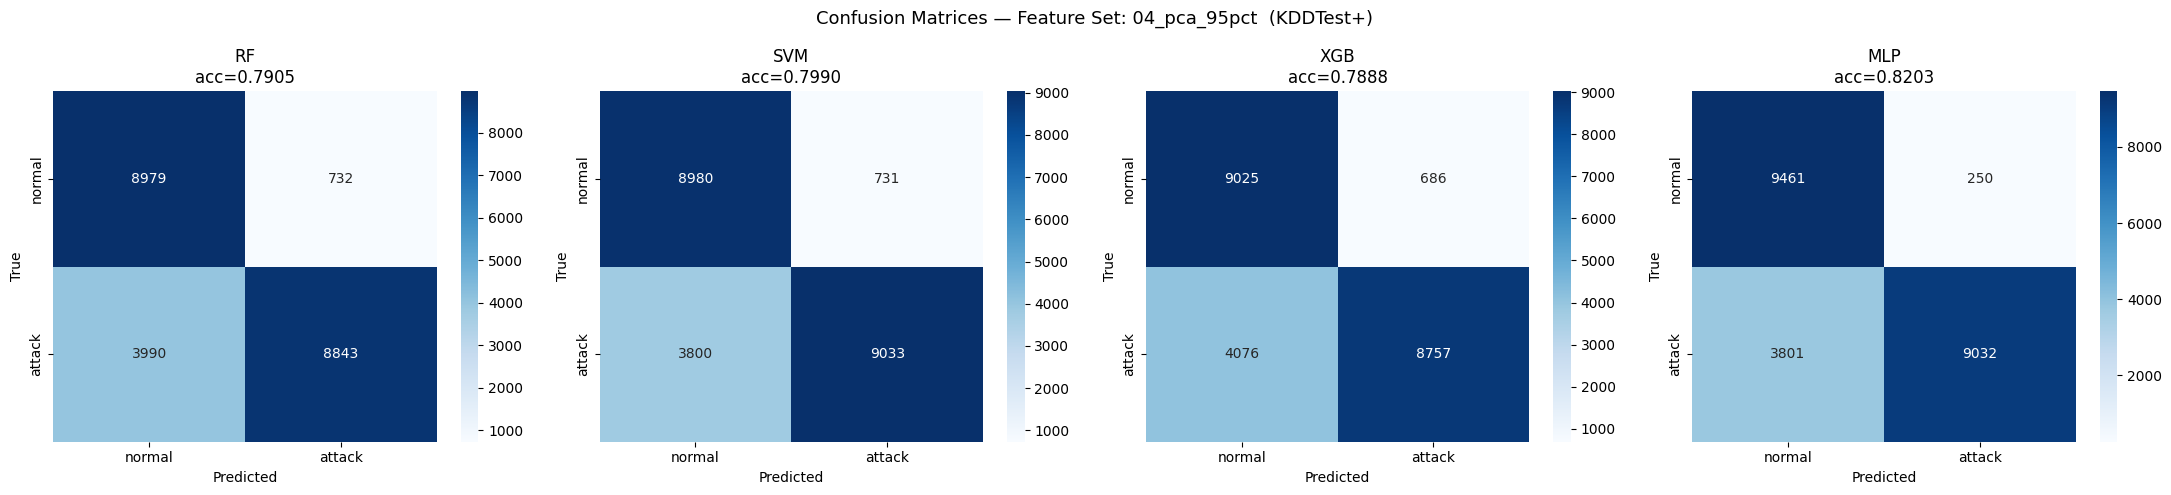

In [19]:
# Confusion matrices — all 4 models on best feature set
model_names = ["RF", "SVM", "XGB", "MLP"]
fig, axes   = plt.subplots(1, 4, figsize=(22, 5))

for ax, mn in zip(axes, model_names):
    m = best_estimators[best_fs].get(mn)
    if m is None:
        ax.set_visible(False)
        continue
    yp_m = np.argmax(m.predict(X_best_te, verbose=0), axis=1) if mn == "MLP" \
           else m.predict(X_best_te)
    cm = confusion_matrix(y_test, yp_m)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["normal","attack"], yticklabels=["normal","attack"])
    ax.set_title(f"{mn}\nacc={accuracy_score(y_test, yp_m):.4f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.suptitle(f"Confusion Matrices — Feature Set: {best_fs}  (KDDTest+)", fontsize=13)
plt.tight_layout()
plt.show()

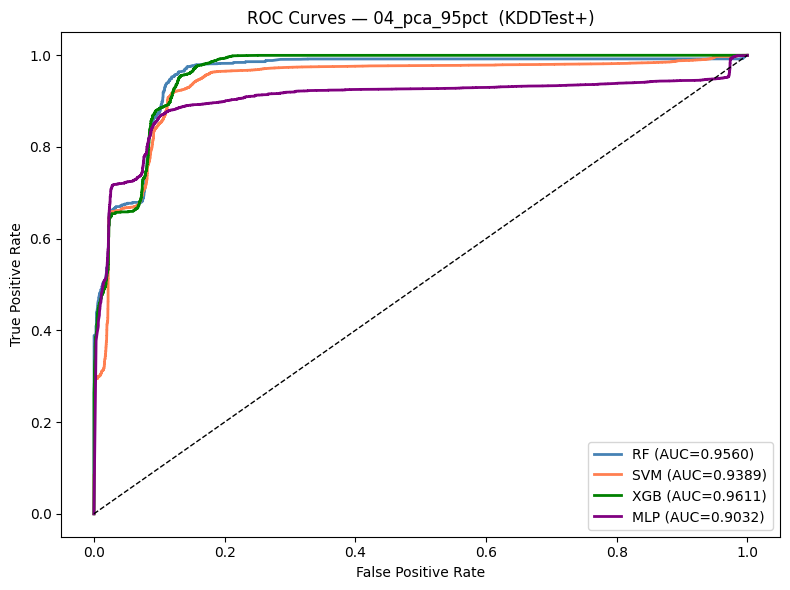

In [20]:
# ROC Curves — all 4 models on best feature set
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 6))
colors  = ["steelblue", "coral", "green", "purple"]

for mn, color in zip(model_names, colors):
    m = best_estimators[best_fs].get(mn)
    if m is None:
        continue
    prob = m.predict(X_best_te, verbose=0)[:, 1] if mn == "MLP" \
           else m.predict_proba(X_best_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, label=f"{mn} (AUC={auc:.4f})", color=color, lw=2)

ax.plot([0,1],[0,1], "k--", lw=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC Curves — {best_fs}  (KDDTest+)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 11. GridSearchCV — Highest Accuracy Tuning

5-fold StratifiedKFold GridSearchCV applied to RF, SVM, and XGB on the top-2 feature sets.  
**KDDTest+** is withheld during the entire search — no leakage.

In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

top2_fs = (results_df.groupby("feature_set")["accuracy"]
                     .max()
                     .nlargest(2)
                     .index.tolist())
print(f"GridSearchCV target feature sets: {top2_fs}")

rf_grid = {
    "n_estimators" : [100, 200, 300],
    "max_depth"    : [10, 20, None],
    "max_features" : ["sqrt", "log2"],
}
svm_grid = {
    "C"     : [0.1, 1.0, 10.0],
    "gamma" : ["scale", "auto"],
}
xgb_grid = {
    "n_estimators"  : [100, 200],
    "max_depth"     : [4, 6, 8],
    "learning_rate" : [0.05, 0.1, 0.2],
    "subsample"     : [0.7, 1.0],
}

gs_results    = []
gs_best_models = {}

for fs_name in top2_fs:
    X_tr, X_te = feature_sets[fs_name]
    X_tr = np.array(X_tr)
    X_te = np.array(X_te)
    print(f"\n{'='*60}\nFeature Set: {fs_name}\n{'='*60}")

    # RF
    print("  [RF] GridSearchCV...")
    t0    = time.time()
    gs_rf = GridSearchCV(
        RandomForestClassifier(random_state=42, n_jobs=-1, class_weight="balanced"),
        rf_grid, scoring="accuracy", cv=cv, n_jobs=-1, refit=True, verbose=0
    )
    gs_rf.fit(X_tr, y_train)
    yp  = gs_rf.predict(X_te)
    met = evaluate(y_test, yp, gs_rf.predict_proba(X_te))
    elapsed = round(time.time() - t0, 2)
    print(f"  Best params: {gs_rf.best_params_}")
    print(f"  CV acc={gs_rf.best_score_:.4f}  Test acc={met['accuracy']}  f1={met['f1_weighted']}  ({elapsed}s)")
    gs_results.append({"feature_set": fs_name, "model": "RF_gs", "cv_score": round(gs_rf.best_score_,4), "time_s": elapsed, **met})

    # SVM
    print("  [SVM] GridSearchCV...")
    t0     = time.time()
    idx    = np.random.default_rng(42).choice(len(X_tr), min(SVM_MAX_ROWS, len(X_tr)), replace=False)
    gs_svm = GridSearchCV(
        SVC(kernel="rbf", degree=3, probability=True, random_state=42, class_weight="balanced"),
        svm_grid, scoring="accuracy", cv=cv, n_jobs=-1, refit=True, verbose=0
    )
    gs_svm.fit(X_tr[idx], y_train.iloc[idx])
    yp  = gs_svm.predict(X_te)
    met = evaluate(y_test, yp, gs_svm.predict_proba(X_te))
    elapsed = round(time.time() - t0, 2)
    print(f"  Best params: {gs_svm.best_params_}")
    print(f"  CV acc={gs_svm.best_score_:.4f}  Test acc={met['accuracy']}  f1={met['f1_weighted']}  ({elapsed}s)")
    gs_results.append({"feature_set": fs_name, "model": "SVM_gs", "cv_score": round(gs_svm.best_score_,4), "time_s": elapsed, **met})

    # XGB
    print("  [XGB] GridSearchCV...")
    t0     = time.time()
    gs_xgb = GridSearchCV(
        XGBClassifier(random_state=42, eval_metric="logloss", n_jobs=1, device=xgb_device),
        xgb_grid, scoring="accuracy", cv=cv, n_jobs=-1, refit=True, verbose=0
    )
    gs_xgb.fit(X_tr, y_train)
    yp  = gs_xgb.predict(X_te)
    met = evaluate(y_test, yp, gs_xgb.predict_proba(X_te))
    elapsed = round(time.time() - t0, 2)
    print(f"  Best params: {gs_xgb.best_params_}")
    print(f"  CV acc={gs_xgb.best_score_:.4f}  Test acc={met['accuracy']}  f1={met['f1_weighted']}  ({elapsed}s)")
    gs_results.append({"feature_set": fs_name, "model": "XGB_gs", "cv_score": round(gs_xgb.best_score_,4), "time_s": elapsed, **met})

print("\nGridSearchCV complete.")

GridSearchCV target feature sets: ['04_pca_95pct', '05_pca_k20']

Feature Set: 04_pca_95pct
  [RF] GridSearchCV...
  Best params: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 300}
  CV acc=0.9979  Test acc=0.7892  f1=0.789  (2743.14s)
  [SVM] GridSearchCV...
  Best params: {'C': 10.0, 'gamma': 'scale'}
  CV acc=0.9937  Test acc=0.8016  f1=0.8017  (615.65s)
  [XGB] GridSearchCV...
  Best params: {'learning_rate': 0.2, 'max_depth': 8, 'n_estimators': 200, 'subsample': 1.0}
  CV acc=0.9982  Test acc=0.7893  f1=0.789  (247.98s)

Feature Set: 05_pca_k20
  [RF] GridSearchCV...
  Best params: {'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 100}
  CV acc=0.9978  Test acc=0.7982  f1=0.7974  (1332.54s)
  [SVM] GridSearchCV...
  Best params: {'C': 10.0, 'gamma': 'auto'}
  CV acc=0.9948  Test acc=0.8341  f1=0.834  (146.27s)
  [XGB] GridSearchCV...
  Best params: {'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.7}
  CV acc=0.9980  Test acc=0.8124  

In [22]:
gs_df = pd.DataFrame(gs_results).sort_values("accuracy", ascending=False).reset_index(drop=True)
print("GridSearchCV Results:")
display(gs_df[["feature_set","model","cv_score","accuracy","f1_weighted","roc_auc","time_s"]])

# Fixed-HP vs GridSearch comparison
compare_df = results_df[results_df["model"].isin(["RF","SVM","XGB"]) &
                        results_df["feature_set"].isin(top2_fs)].copy()
compare_df["variant"] = "fixed"
gs_cmp = gs_df.copy()
gs_cmp["variant"] = "grid_search"
gs_cmp["model"]   = gs_cmp["model"].str.replace("_gs", "")

combined = pd.concat([
    compare_df[["feature_set","model","variant","accuracy","f1_weighted"]],
    gs_cmp[["feature_set","model","variant","accuracy","f1_weighted"]]
]).sort_values(["model","feature_set","variant"])

print("\nFixed HP vs GridSearchCV Comparison:")
display(combined)

GridSearchCV Results:


,feature_set,model,cv_score,accuracy,f1_weighted,roc_auc,time_s
0,05_pca_k20,SVM_gs,0.9948,0.8341,0.8340,0.9259,146.27
1,05_pca_k20,XGB_gs,0.9980,0.8124,0.8115,0.9618,101.60
2,04_pca_95pct,SVM_gs,0.9937,0.8016,0.8017,0.9317,615.65
3,05_pca_k20,RF_gs,0.9978,0.7982,0.7974,0.9627,1332.54
4,04_pca_95pct,XGB_gs,0.9982,0.7893,0.7890,0.9596,247.98
5,04_pca_95pct,RF_gs,0.9979,0.7892,0.7890,0.9554,2743.14



Fixed HP vs GridSearchCV Comparison:


,feature_set,model,variant,accuracy,f1_weighted
6,04_pca_95pct,RF,fixed,0.7905,0.7904
5,04_pca_95pct,RF,grid_search,0.7892,0.7890
3,05_pca_k20,RF,fixed,0.8088,0.8079
3,05_pca_k20,RF,grid_search,0.7982,0.7974
5,04_pca_95pct,SVM,fixed,0.7990,0.7991
2,04_pca_95pct,SVM,grid_search,0.8016,0.8017
8,05_pca_k20,SVM,fixed,0.7888,0.7885
0,05_pca_k20,SVM,grid_search,0.8341,0.8340
9,04_pca_95pct,XGB,fixed,0.7888,0.7884
4,04_pca_95pct,XGB,grid_search,0.7893,0.7890


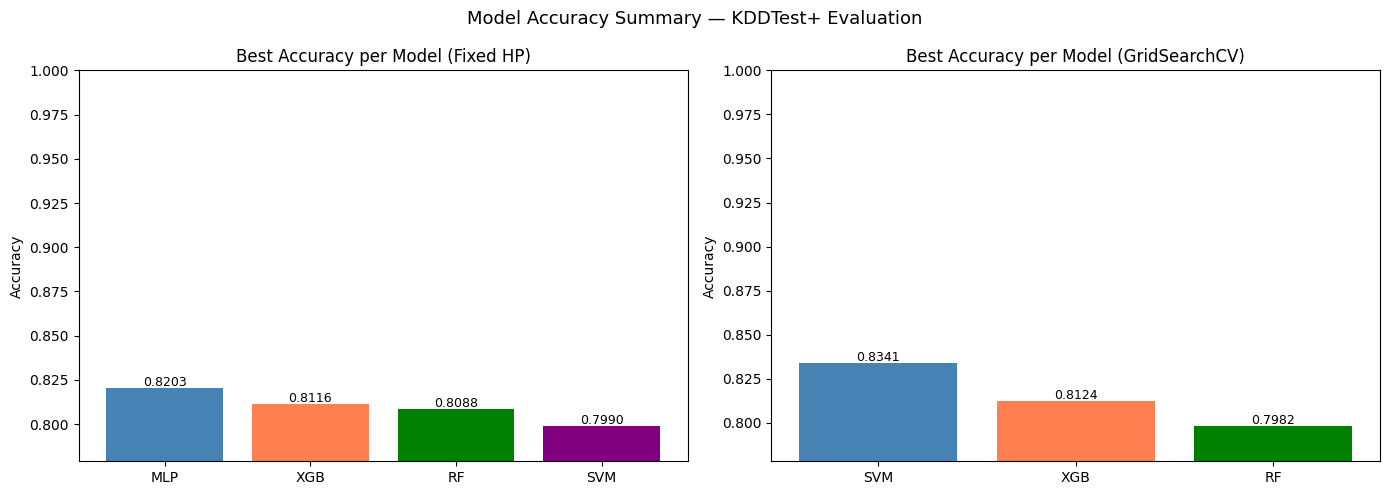

In [23]:
# Summary bar charts: Fixed HP vs GridSearch best accuracy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

best_per_model = results_df.groupby("model")["accuracy"].max().sort_values(ascending=False)
axes[0].bar(best_per_model.index, best_per_model.values,
            color=["steelblue","coral","green","purple"][:len(best_per_model)])
axes[0].set_title("Best Accuracy per Model (Fixed HP)")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(best_per_model.min() - 0.02, 1.0)
for i, v in enumerate(best_per_model.values):
    axes[0].text(i, v + 0.001, f"{v:.4f}", ha="center", fontsize=9)

best_gs = gs_df.copy()
best_gs["model"] = best_gs["model"].str.replace("_gs", "")
best_gs_model    = best_gs.groupby("model")["accuracy"].max().sort_values(ascending=False)
axes[1].bar(best_gs_model.index, best_gs_model.values,
            color=["steelblue","coral","green"][:len(best_gs_model)])
axes[1].set_title("Best Accuracy per Model (GridSearchCV)")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(best_gs_model.min() - 0.02, 1.0)
for i, v in enumerate(best_gs_model.values):
    axes[1].text(i, v + 0.001, f"{v:.4f}", ha="center", fontsize=9)

plt.suptitle("Model Accuracy Summary — KDDTest+ Evaluation", fontsize=13)
plt.tight_layout()
plt.show()

In [24]:
# Save results
results_df.to_csv("results_fixed_hp_train+_test+.csv",   index=False)
gs_df.to_csv("results_gridsearch_train+_test+.csv",       index=False)
print("Saved: results_fixed_hp_train+_test+.csv, results_gridsearch_train+_test+.csv")

Saved: results_fixed_hp_train+_test+.csv, results_gridsearch_train+_test+.csv
